### Task Description:
#### Train a ML method to recognize <font color=red> Plant Species </font> based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm).
- In the TXT file, you will find an experiment conducted on four different species (Cs = Cucumber, Sl = Tomato, Zm = Maize, Hv = Barley) grown under Fe-deficient conditions.
- Each row refers to a different plant, while the columns indicate the values at various wavelengths of the reflectance spectrum (from 400 to 1000 nm).
- The second column contains the plant species information ("Species": Cs is cucumber, Zm is maize, Sl is tomato, Hv is barley).
- The third column contains the treatment information ("Thesis": +N-Fe indicates iron deficiency, +N+Fe indicates iron sufficiency).

#### Methods
- Linear Logistic Regression
- Polynomial Logistic Regression
- Random Forest

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
import shap
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()

#### Load and Preprocess
- Drop the 'Leaf' column as it has the same value 'YL' for all rows
- Drop “Thesis” Column
- Encode the ‘Species' column (the ground-truth label)
- Separate the dataset into features and labels
- Check class imbalance in the whole dataset
- Check for missing values (there was none)
- Identify outliers using the IQR method ---> <font color=red> I did not drop them </font>
- Feature selection using Random Forest ---> <font color=red> 101 non-important features out of 204 </font>
- Scale the feature values (here, Columns) using Z-Score

In [6]:
# This cell is for selecting (randomly) 36 sample of eddited version of "Michele" into the original dataset, 9 sample per each plant

# Load both text files
df_first = pd.read_csv("Exp_I_Anna_Fe_Tomato.txt", delimiter="\t")  
df_second = pd.read_csv("Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt", delimiter="\t")

# Ensure 'Species' column exists in df_first
if 'Specie' not in df_first.columns:
    raise ValueError("Column 'Specie' not found in first file!")

# Randomly sample 9 rows per plant type (keeping entire rows)
samples_to_add = df_first.groupby("Specie", group_keys=False).apply(lambda x: x.sample(n=9, random_state=42))

# Reset index to preserve row structure
# samples_to_add = samples_to_add.reset_index(drop=True)
samples_to_add = samples_to_add.reindex(columns=df_second.columns, fill_value=float("nan"))

# Append the selected rows to df_second WITHOUT considering column names
df_updated = pd.concat([df_second, samples_to_add], axis=0, ignore_index=True)

# Save the updated file
df_updated.to_csv("Dati_HIS_mly.txt", sep="\t", index=False)

print("Successfully added 9 full rows per plant type without considering column names!")


Successfully added 9 full rows per plant type without considering column names!


C:\Users\hassa\AppData\Local\Temp\ipykernel_13776\976317151.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_to_add = df_first.groupby("Specie", group_keys=False).apply(lambda x: x.sample(n=9, random_state=42))


Class Distribution:
Species
Cs    36
Sl    36
Hv    36
Zm    36
Name: count, dtype: int64


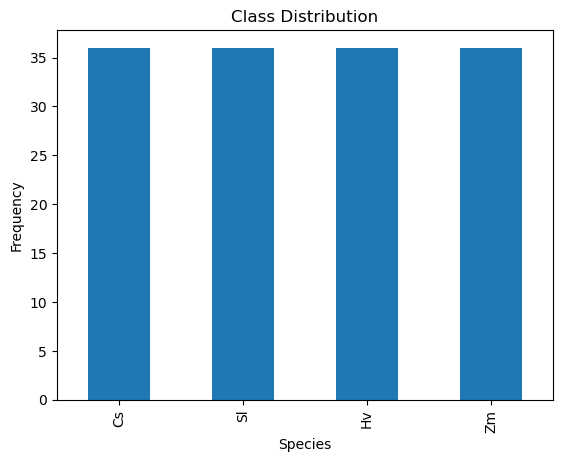


Number of features with 0.0 importance: 0
Features with 0.0 importance: []
X_scaled is (144, 25)
[[-0.4908298  -0.84368335 -0.84116705 ...  0.52605325 -0.66201608
  -0.73206596]
 [-0.51174934 -0.79889867 -0.79746199 ...  0.3068551  -0.65381056
  -0.71596807]
 [-0.73131911 -0.81409832 -0.80715955 ...  0.31237925 -0.66394024
  -0.7761796 ]
 ...
 [ 1.84329815  1.52876813  1.52664183 ... -0.05142879  2.01000624
   2.07879761]
 [ 1.70505311  1.63947197  1.639062   ... -0.3658681   2.06899266
   2.05824036]
 [ 1.42371307  1.53968862  1.53160518 ... -1.04436933  1.96442661
   1.93817985]]
y is (144,)
  Specie Fe_deficiency  Replicates    397.32     400.2    403.09    405.97  \
0     Sl         +N+Fe           1  0.138507  0.120903  0.107281  0.099468   
1     Sl         +N+Fe           2  0.153739  0.134105  0.118036  0.108338   
2     Sl         +N+Fe           3  0.156368  0.137271  0.118881  0.109219   
3     Sl         +N+Fe           4  0.171283  0.148006  0.130491  0.119070   
4     Sl

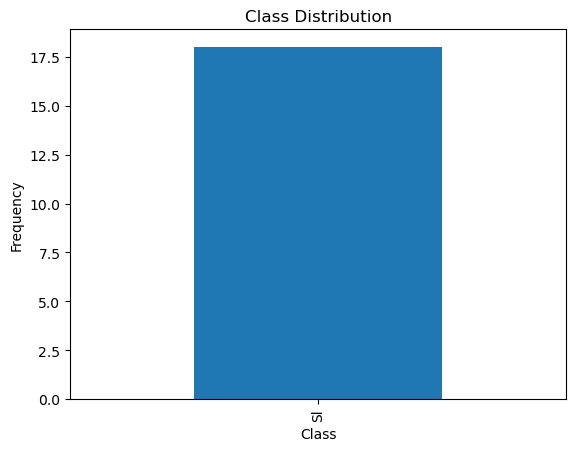

Columns with missing values: []
X_scaled_te is (18, 25)
[[-0.4908298  -0.84368335 -0.84116705 ...  0.52605325 -0.66201608
  -0.73206596]
 [-0.51174934 -0.79889867 -0.79746199 ...  0.3068551  -0.65381056
  -0.71596807]
 [-0.73131911 -0.81409832 -0.80715955 ...  0.31237925 -0.66394024
  -0.7761796 ]
 ...
 [ 1.84329815  1.52876813  1.52664183 ... -0.05142879  2.01000624
   2.07879761]
 [ 1.70505311  1.63947197  1.639062   ... -0.3658681   2.06899266
   2.05824036]
 [ 1.42371307  1.53968862  1.53160518 ... -1.04436933  1.96442661
   1.93817985]]
y_te is (18,)


In [128]:
# Step 1: Load the dataset

# data = pd.read_csv('modified_train_set_original.txt', delimiter='\t')

data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')

# Step 2: Preprocess the data
# Drop the 'Leaf' column
data = data.drop(columns=['Leaf'])

# Separate the dataset into features and labels
# X = data.iloc[:, 3:]
# X = data.iloc[:, 21:125]  # Select feature columns
# X = data.iloc[:, 21:190] #Trimmed

#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED, Apply SHAP on Train ####
# Use Logistic Regression's SHAP features, all plants
desired_columns = ['X714.55', 'X455.16', 'X452.25', 'X458.06', 'X449.35', 'X460.96', 'X478.41', 'X475.50', 'X481.32',
'X463.87', 'X466.77',
'X717.54', 'X723.53', 'X726.53', 'X720.54', 'X729.53', 'X711.56', 'X708.57',
'X747.54', 'X753.55', 'X687.65', 'X690.64', 'X750.54', 'X684.67', 'X693.62']

# Use Logistic Regression's SHAP features, related to Sl/Tomato
# desired_columns = ['X717.54','X714.55', 'X723.53','X726.53', 'X720.54', 'X729.53', 'X711.56', 'X708.57','X747.54']

# Use Random Forest's SHAP features
# desired_columns = ['X449.35', 'X452.25', 'X455.16', 'X481.32', 'X501.72', 'X487.14', 'X463.87', 'X492.97', 'X475.50',
# 'X472.59', 'X490.06', 'X711.56', 
# 'X507.56', 'X675.73', 'X495.89']

X = data[desired_columns]

y = data['Species']  # Target variable
feature_names = X.columns.tolist()

# Encode the 'Species' column (target variable)
le = LabelEncoder()
y = le.fit_transform(y)
# Check the distribution/imbalance of the target variable
class_distribution = data['Species'].value_counts()
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Species')
plt.ylabel('Frequency')
plt.show()


# Step 3: Check for missing values
missing_columns = data.columns[data.isnull().any()].tolist()
if missing_columns:
    print(f"Columns with missing values: {missing_columns}")
    data.fillna(data.mean(), inplace=True)

# Step 4: Feature selection using RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# Step 5: Scale the feature values
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
print("Features with 0.0 importance:", zero_importance_features)
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced .columns.tolist()
# print("\nX_reduced.shape is ", X_reduced.shape)
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# Scale the feature values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)


# # Extra prints for debugging
print("X_scaled is",X_scaled.shape)
print (X_scaled)
print("y is", y.shape)
# print(y)
#/////////////////////////////////////////////////////////

# Step 1: Load the dataset

# test_df = pd.read_csv('Anna2new.txt', delimiter='\t')
## Sheet 1
test_df = pd.read_csv('Exp_I_Anna_Fe_Tomato.txt', delimiter='\t')
# test_df = pd.read_csv('Exp_II_Anna_Fe_Tomato.txt', delimiter='\t')
## Sheet 4
# test_df = pd.read_csv('Exp_Marco_tesista_Fe_Lupino.txt', delimiter='\t')

# Rename the column "Fe deficiency" to "Thesis"
test_df.rename(columns={'Fe_deficiency ': 'Thesis'}, inplace=True)

# Verify the change
print(test_df.head())


# Separate the dataset into features and labels
# X_te = test_df.iloc[:, 3:]
# X_te = test_df.iloc[:, 21:125]
# X_te = test_df.iloc[:, 21:190]  # Use test_df here, not data


#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED, Apply SHAP on TRain ####
# Use Logistic Regression's SHAP features, related to 4 plants 
desired_columns1 = ['714.55', '455.16', '452.25', '458.06', '449.35', '460.96', '478.41', '475.5', '481.32',
'463.87', '466.77',
'717.54', '723.53', '726.53', '720.54', '729.53', '711.56', '708.57',
'747.54', '753.55', '687.65', '690.64', '750.54', '684.67', '693.62']

# Use Logistic Regression's SHAP features, related to Sl/Tomato
# desired_columns1 = ['717.54','714.55', '723.53','726.53', '720.54', '729.53', '711.56', '708.57','747.54']

# Use Random Forest's SHAP features
# desired_columns1 = ['449.35', '452.25', '455.16', '481.32', '501.72', '487.14', '463.87', '492.97', '475.5',
# '472.59', '490.06', '711.56', 
# '507.56', '675.73', '495.89']

X_te = test_df[desired_columns1]
# Ensure that X_te has the correct number of columns as X
X_te.columns = X.columns  # Update the column names to match those in X

#################new
# Encode the 'Species' column in the test set using the same LabelEncoder
y_te = le.transform(test_df['Specie'])
# Verify the alignment
print("Encoded labels in training set:", le.classes_)
print("Encoded labels in test set:", y_te)
################# end of new

# Check the distribution/imbalance of the target variable
class_distribution = test_df['Specie'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()



# Check for missing values --> none
print(f"Columns with missing values: {test_df.columns[test_df.isnull().any()].tolist()}")

X_scaled_te = scaler.fit_transform(X_te)


# Extra prints for debugging
print("X_scaled_te is",X_scaled_te.shape)
print (X_scaled)
print("y_te is", y_te.shape)
# print(y)


In [111]:
print("Shape of X_te:", X_te.shape)  # Number of rows and columns
print("Shape of test_df:", test_df.shape)  # Total rows and columns in the test set


Shape of X_te: (18, 169)
Shape of test_df: (18, 207)


#### The following cell is related to "train & test" split which is under discussion
- Plan A: Blindly trust "train_test_split()" function
- Plan B: Manually, decompose the dataset based on plant type, Shuffle and Split (75% for Train and 25% for Test) Within Each Plant Species and 2) Combine the Splits
- Plan C: ?!?

In [124]:
# # Step 3: Train-Test Split
# 😎😎😎😎😎😎 new line
# Plan D split
X_train, y_train = X_scaled, y
X_test, y_test = X_scaled_te, y_te

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


# # New
# from sklearn.preprocessing import QuantileTransformer

# qt = QuantileTransformer(output_distribution='normal', random_state=42)
# X_train_transformed = qt.fit_transform(X_train)
# X_test_transformed = qt.transform(X_test)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


X_train shape: (144, 25), y_train shape: (144,)
X_test shape: (18, 25), y_test shape: (18,)


In [125]:


# print("Label Encoding Mapping in the Second Dataset (Based on First Dataset):")
# for label, encoded_value in species_mapping.items():  # Use the species_mapping dictionary
#     print(f"{label}: {encoded_value}")

# # Check if the mapping was applied correctly
# print("\nEncoded labels in the second dataset:")
# print(y_te.unique())  # Print unique encoded values in y_te

# # Verify the alignment with the first dataset's mapping
# if set(y_te.unique()) != set(species_mapping.values()):
#     print("\nWarning: Encoded labels in the second dataset do not match the expected values!")
# else:
#     print("\nSuccess: Labels in the second dataset match the expected encoding.")

print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")
print("Unique labels in y (training set):", np.unique(y))
print("Unique labels in y_te (test set):", np.unique(y_te))



# print("Label Encoding Mappingin the 1st dataset:")
# for i, label in enumerate(le.classes_):
#     print(f"{label}: {i}")
    
# # Print the manually mapped labels for the test set
# print("\nManually mapped labels for the test set:")
# for label, encoded in manual_mapping.items():
#     print(f"{label}: {encoded}")

Label Encoding Mapping:
Cs: 0
Hv: 1
Sl: 2
Zm: 3
Unique labels in y (training set): [0 1 2 3]
Unique labels in y_te (test set): [2]


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Polynomial Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> Standard Logistic Regression </font>

Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'newton-cg'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.615714        0.148752   
1          0.615238        0.133330   
2          0.615238        0.133330   
3          0.622381        0.140182   
4          0.760476        0.128396   
5          0.753810        0.131329   
6          0.760476        0.128396   
7          0.760476        0.128396   
8          0.864286        0.097293   
9          0.864286        0.097293   
10         0.864286        0.097293   
11         0.864286        0.097293   
12         0.924762        0.063774   
13         0.938571        0.070709   
14         0.918095        0.065976   
15         0.910952        0.060349   
16         0.945238        0.073006   
17         0.951905        0.061591   
18         0.938095        0.070759   
19         0.918095        0.065976   

                                            

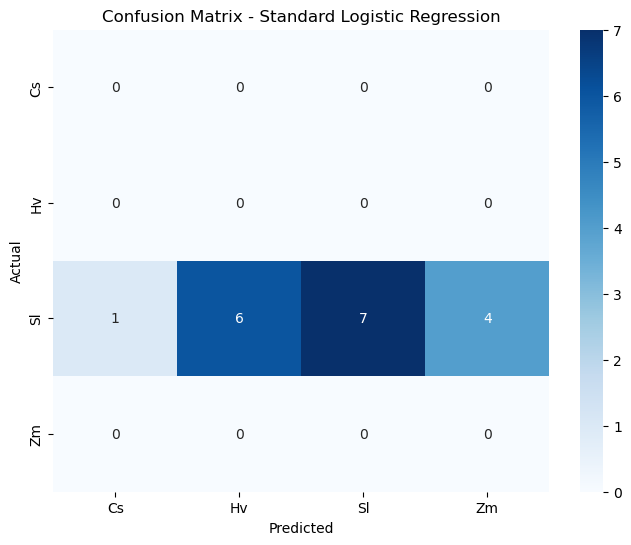

(144, 25, 4)
Generating SHAP plots for Class: Cs


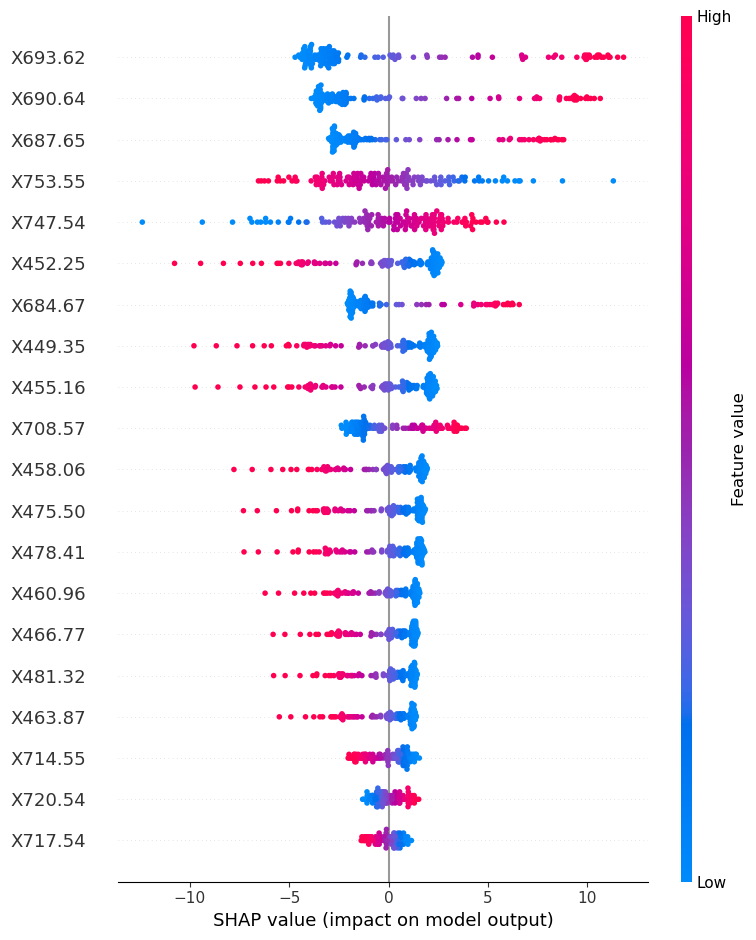

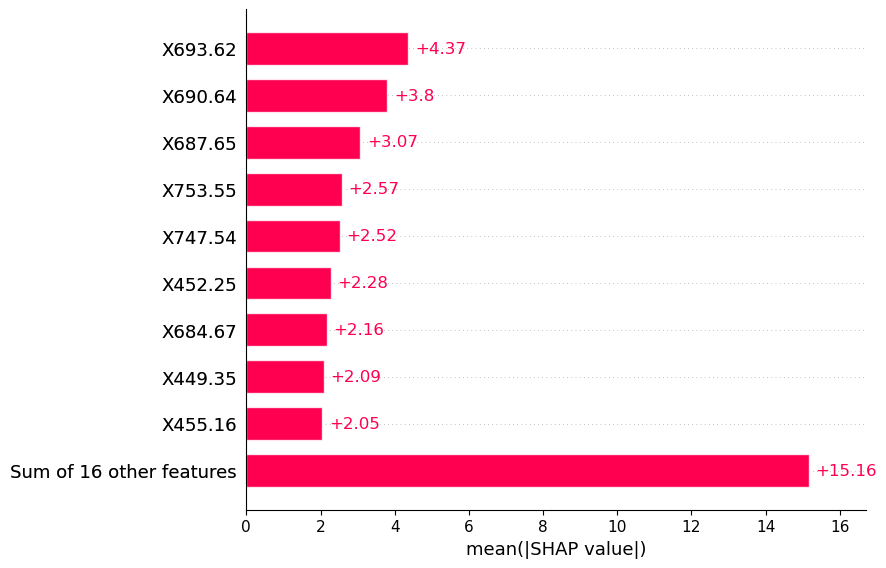

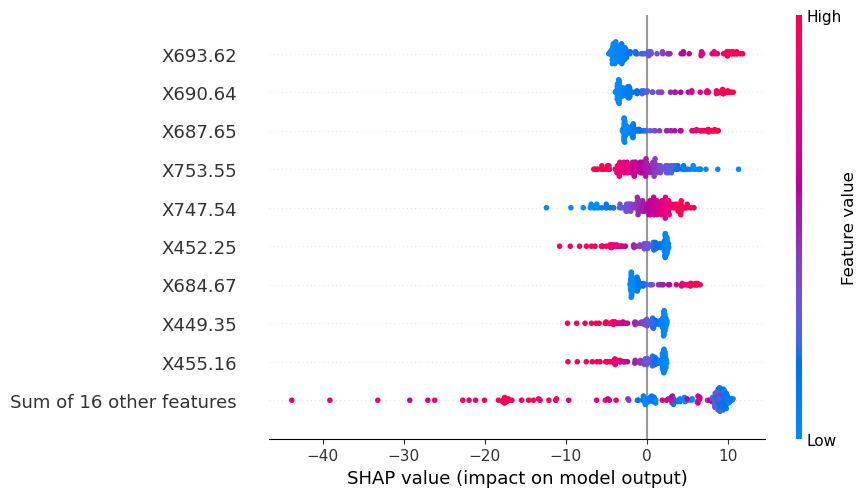

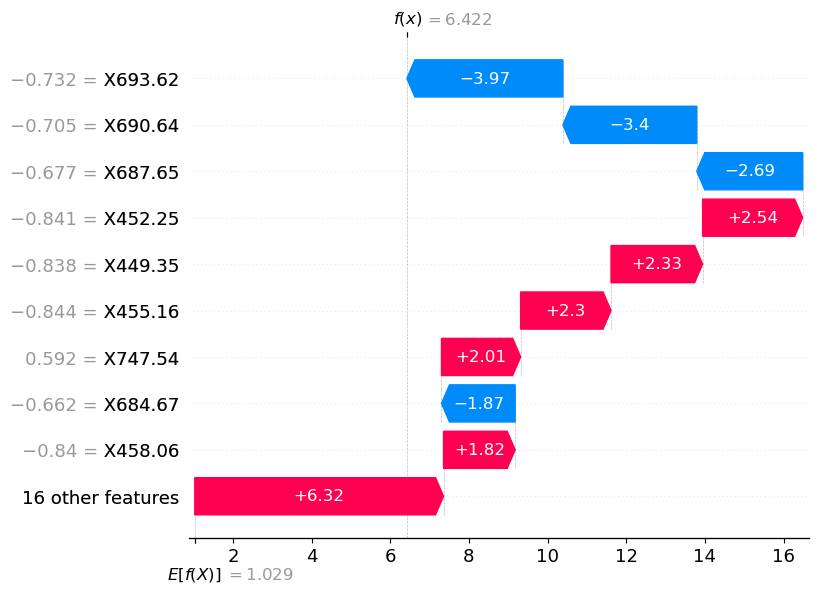

Generating SHAP plots for Class: Hv


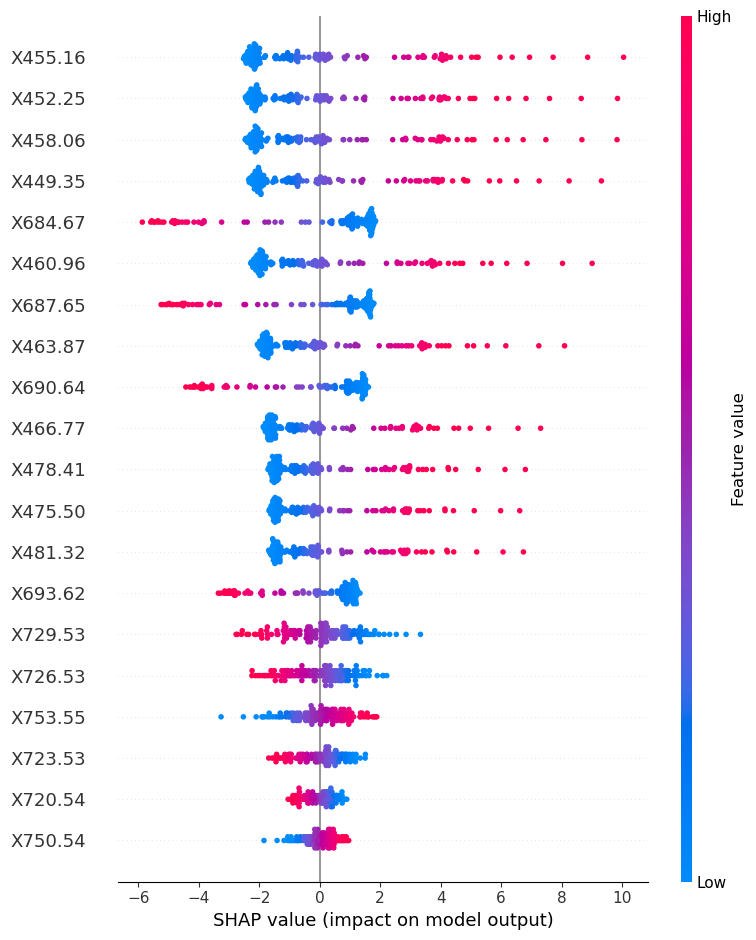

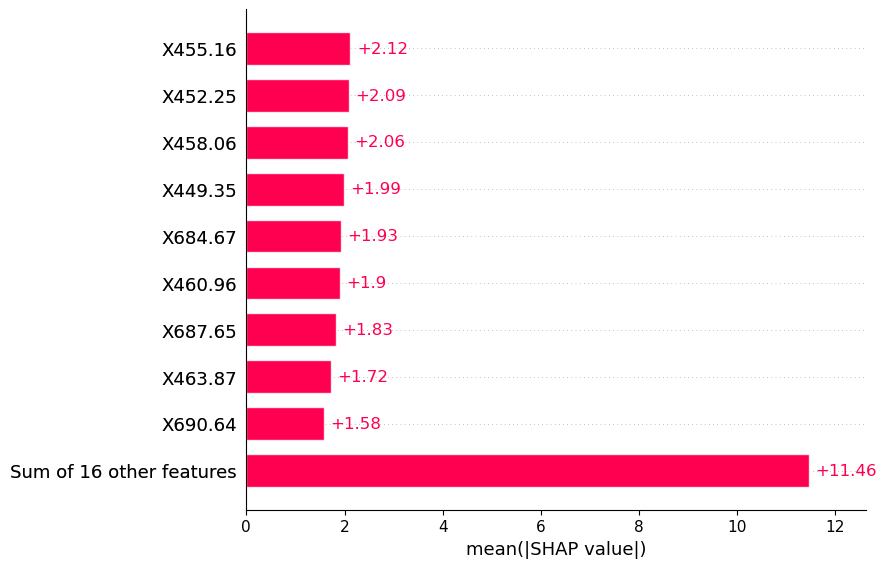

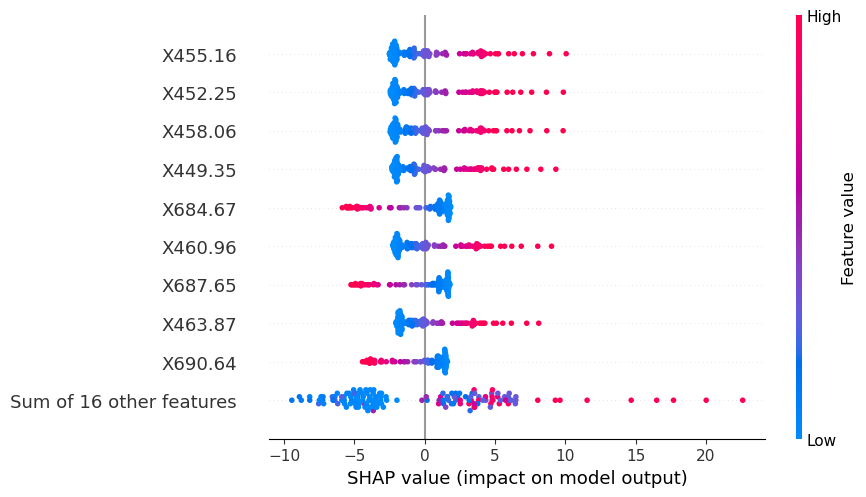

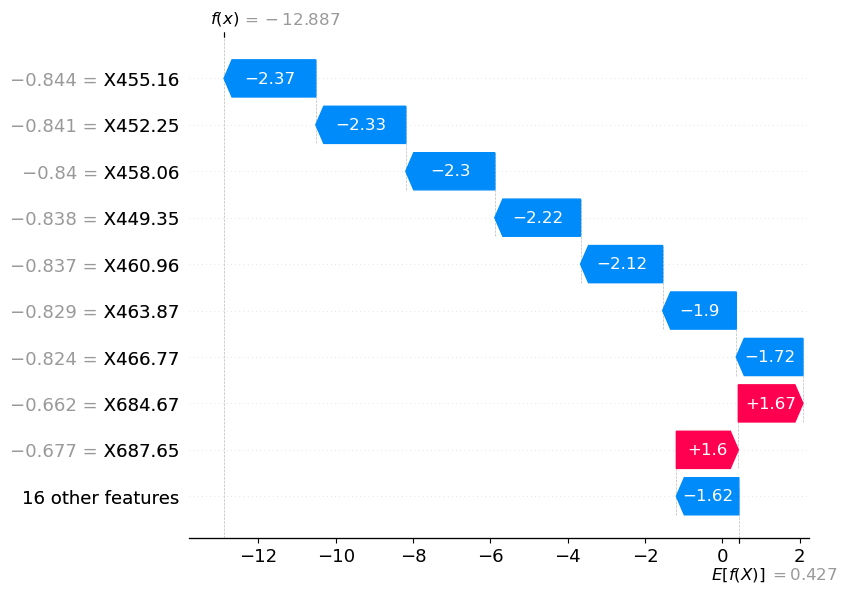

Generating SHAP plots for Class: Sl


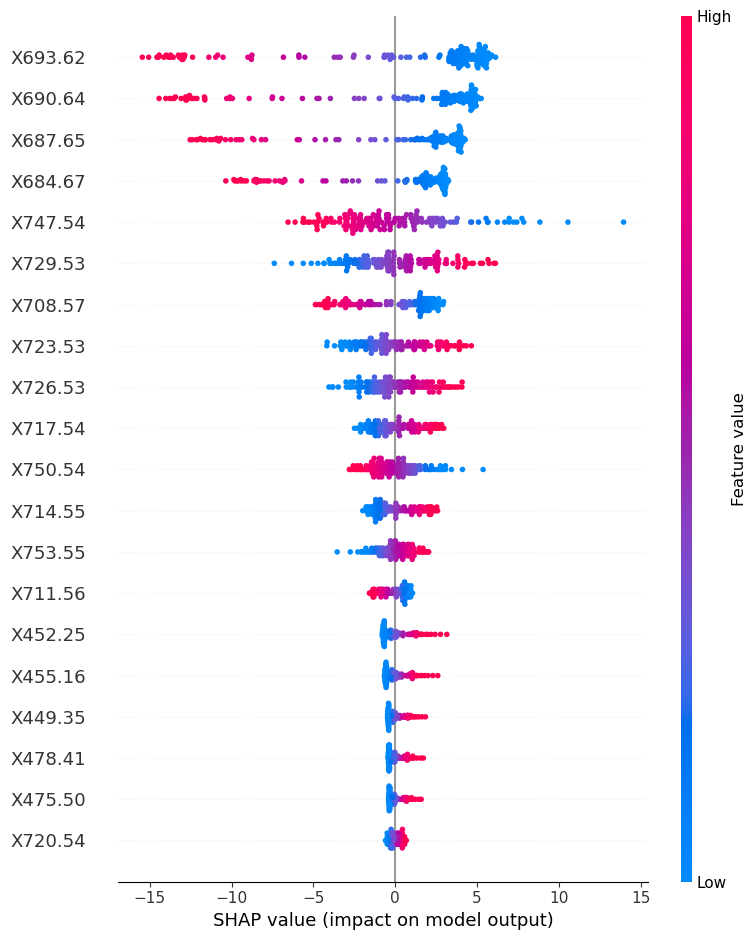

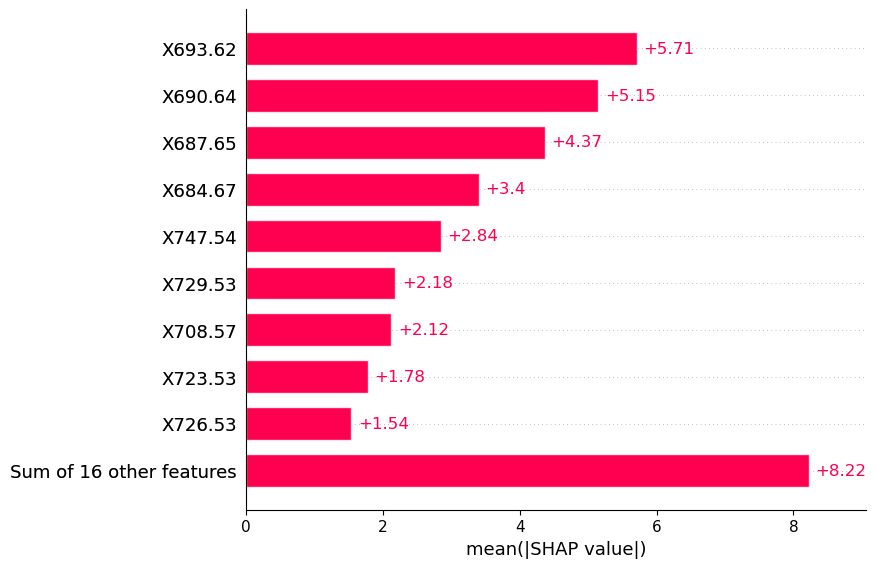

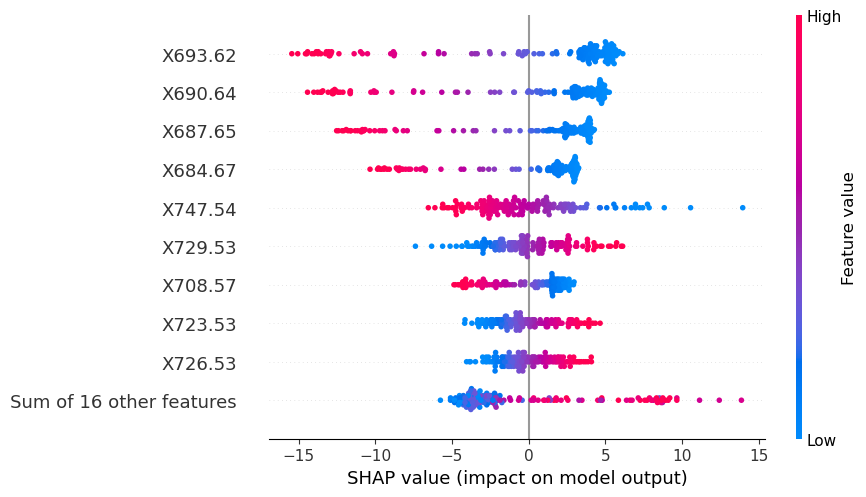

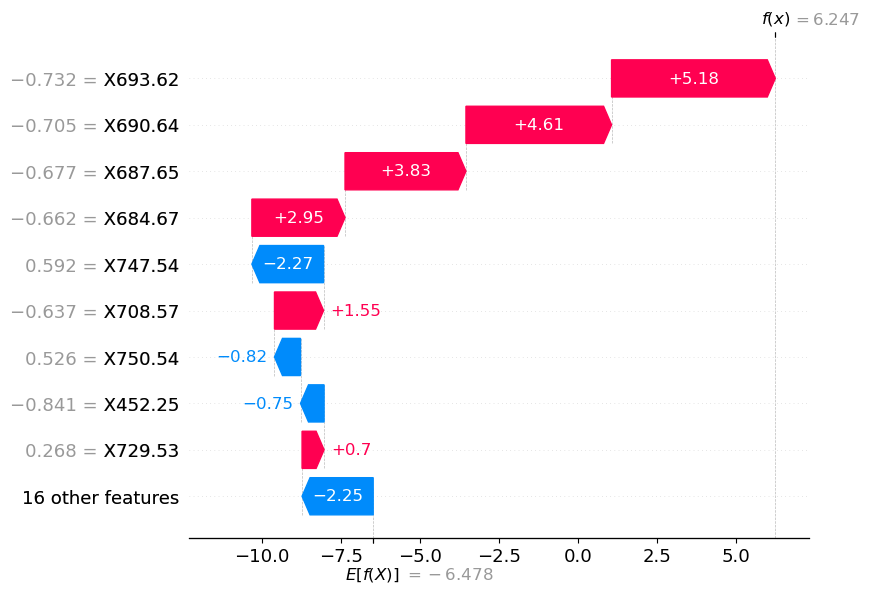

Generating SHAP plots for Class: Zm


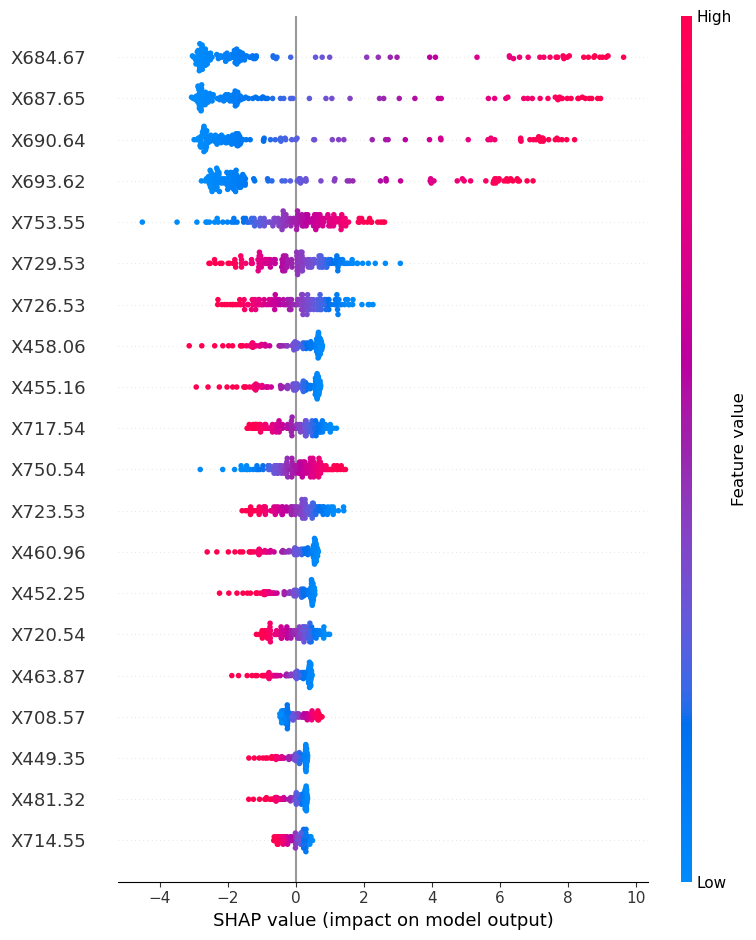

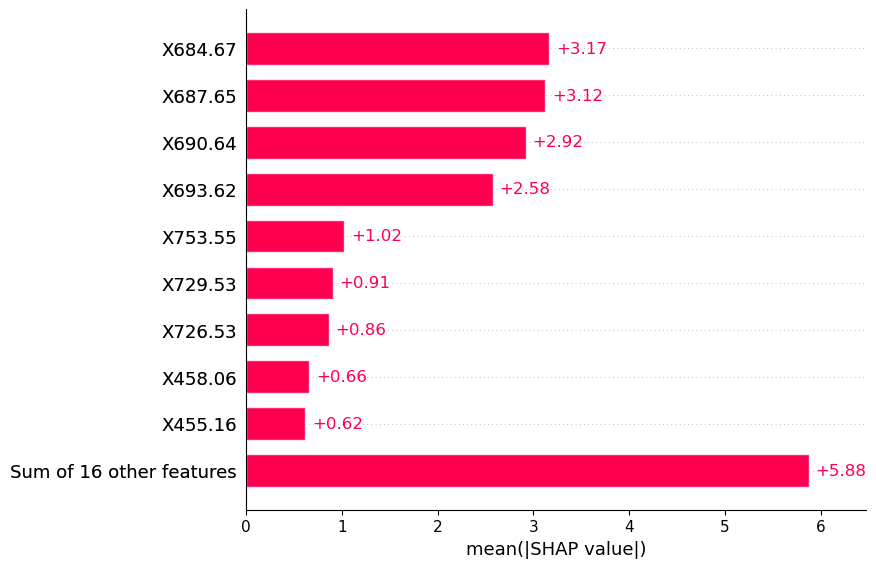

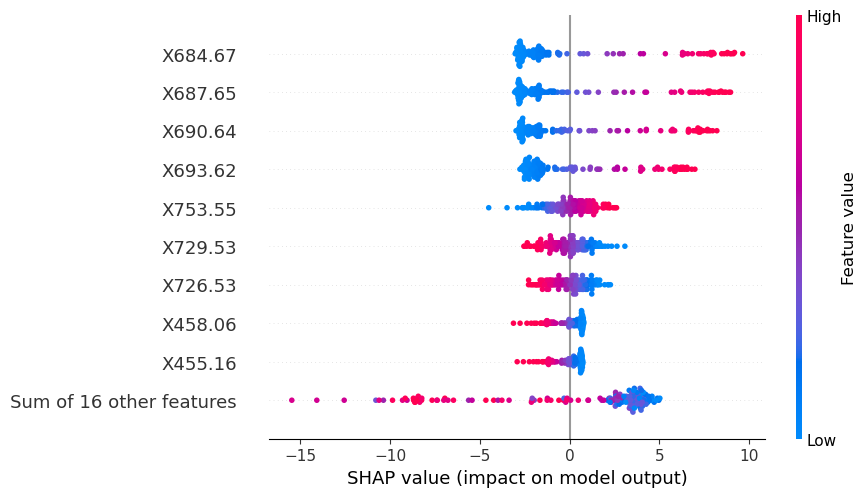

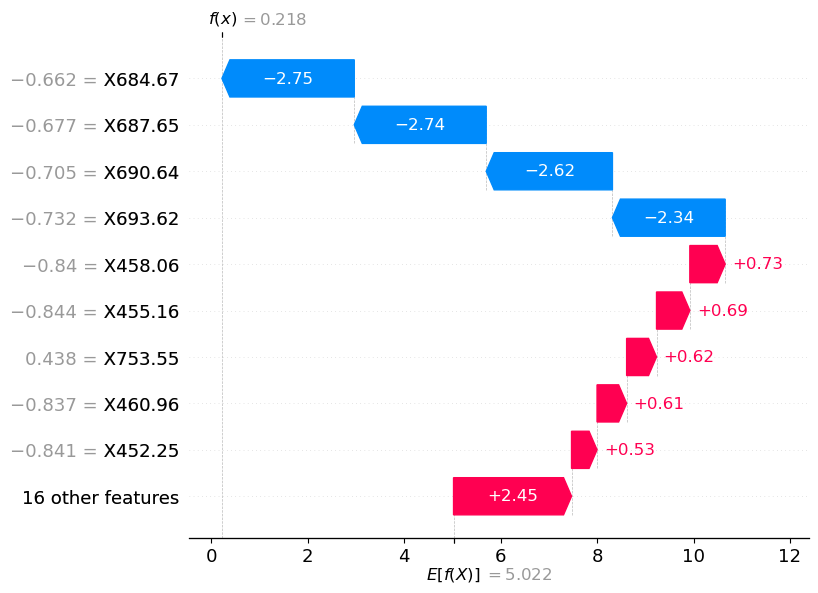

In [126]:
# Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
}

random_state = 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state), 
                              param_grid_lr, cv=10, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# Perform cross-validation
cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
# y_pred_proba = model.predict_proba(X_test)  # Get the predicted probabilities

# Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("Test Set Classification Report:")
# print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


# # Print the predicted probabilities for the first few instances in the test set
# print("\nPredicted Probabilities (first 5 instances):")
# print(y_pred_proba.shape)
# print(y_pred_proba[:5])
      
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# SHAP
explainer = shap.Explainer(model, X_train)
# shap_values = explainer(X_test)
shap_values = explainer(X_train)

# Check the shape of shap_values
print(shap_values.shape)  # Should output (number_of_samples, number_of_features, number_of_classes)

# Generate all SHAP plots for each class
for i in range(shap_values.shape[2]):
    print(f"Generating SHAP plots for Class: {le.classes_[i]}")

    # Summary Plot
    # Apply SHAP on Train set
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=feature_names, class_names=le.classes_)
    # Apply SHAP on Test set
    # shap.summary_plot(shap_values[:, :, i], X_test, feature_names=feature_names, class_names=le.classes_)
    # shap.summary_plot(shap_values[:, :, i], X_test, feature_names=feature_names_reduced, class_names=le.classes_)
    # Bar Plot
    # Apply SHAP on Train set
    shap.plots.bar(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_train, feature_names=feature_names), max_display=10)
    # Apply SHAP on Test set
    # shap.plots.bar(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names), max_display=10)
    # shap.plots.bar(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names_reduced), max_display=10)
    # Beeswarm Plot
    # Apply SHAP on Train set
    shap.plots.beeswarm(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_train, feature_names=feature_names))
    # Apply SHAP on Test set
    # shap.plots.beeswarm(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names))
    # shap.plots.beeswarm(shap.Explanation(values=shap_values[:, :, i], base_values=shap_values.base_values[:, i], data=X_test, feature_names=feature_names_reduced))
    # Waterfall Plot for the first instance
   # Apply SHAP on Train set
    shap.plots.waterfall(shap.Explanation(values=shap_values[0, :, i], base_values=shap_values.base_values[0, i], data=X_train[0], feature_names=feature_names))
    # Apply SHAP on Test set
    # shap.plots.waterfall(shap.Explanation(values=shap_values[0, :, i], base_values=shap_values.base_values[0, i], data=X_test[0], feature_names=feature_names))
    # shap.plots.waterfall(shap.Explanation(values=shap_values[0, :, i], base_values=shap_values.base_values[0, i], data=X_test[0], feature_names=feature_names_reduced))

In [39]:
print("Original test labels in y_test:", y_test)
print("Unique values in y_test:", np.unique(y_test))


Original test labels in y_test: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Unique values in y_test: [2]


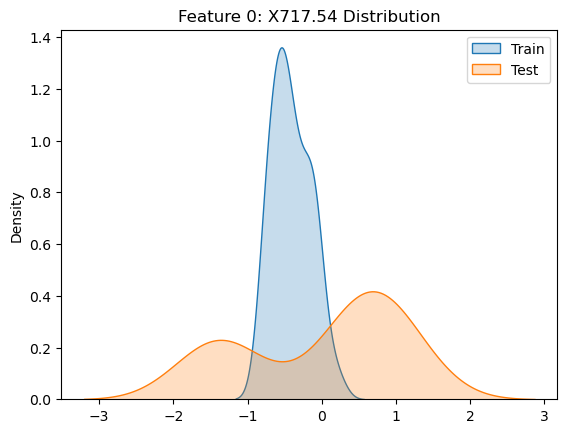

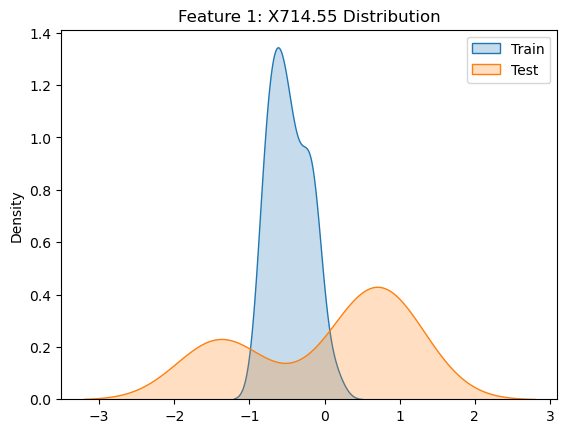

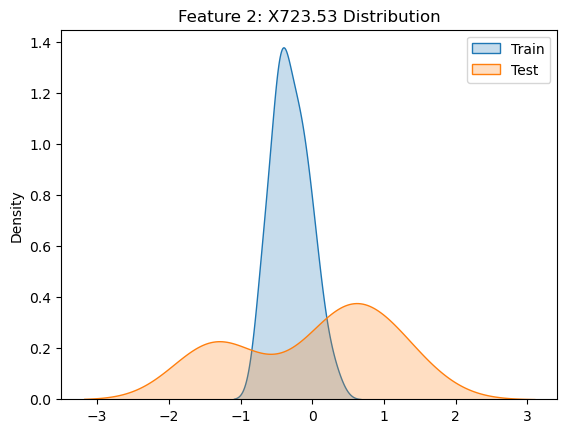

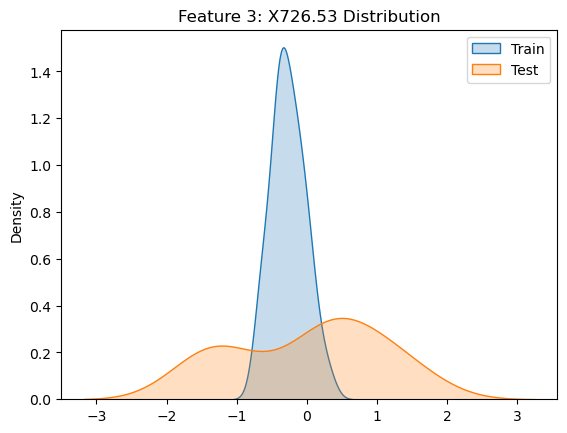

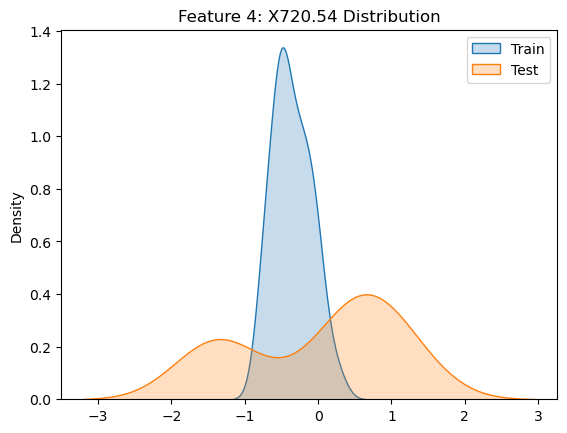

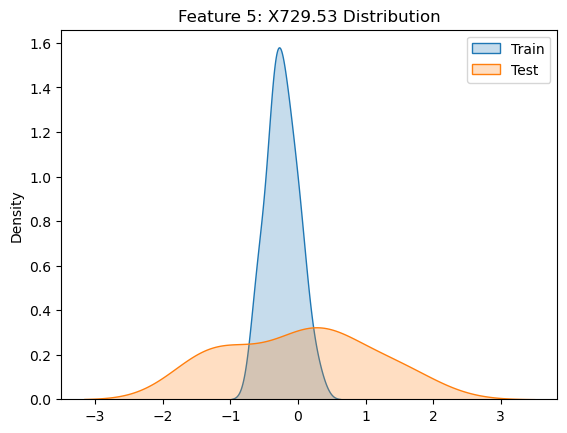

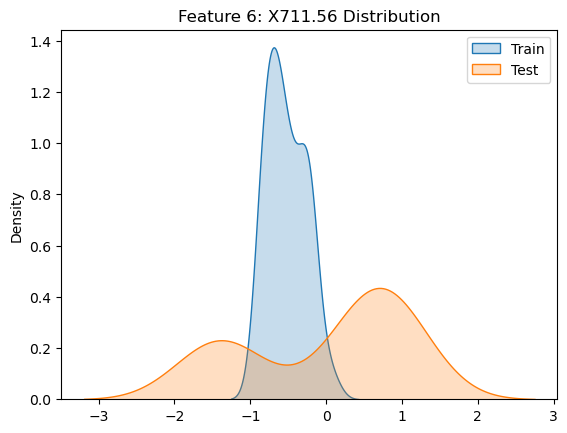

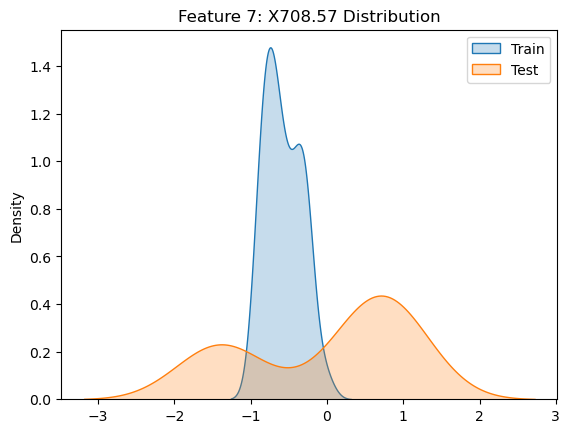

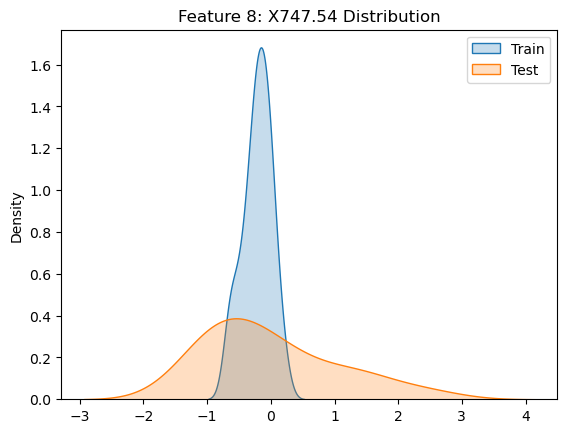

In [61]:
for i in range(X_train.shape[1]):  # Loop over features
    plt.figure()
    # sns.kdeplot(X_train[:, i], label="Train", fill=True)
    # Only Tomatoes
    sns.kdeplot(X_train[36:72, i], label="Train", fill=True)
    sns.kdeplot(X_test[:, i], label="Test", fill=True)
    # Use feature_names[i] to display the real feature name
    plt.title(f"Feature {i}: {feature_names[i]} Distribution")
    plt.legend()
    plt.show()


In [19]:
print(y_train[36:72])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


#### <font color=green> Random Forest </font>

C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.876326        0.062805   
1           0.876136        0.056551   
2           0.882386        0.046563   
3           0.876136        0.056551   
4           0.882576        0.053966   
..               ...             ...   
283         0.869886        0.075579   
284         0.864015        0.067448   
285         0.863826        0.073375   
286         0.863826        0.073375   
287         0.869886        0.075579   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': 's

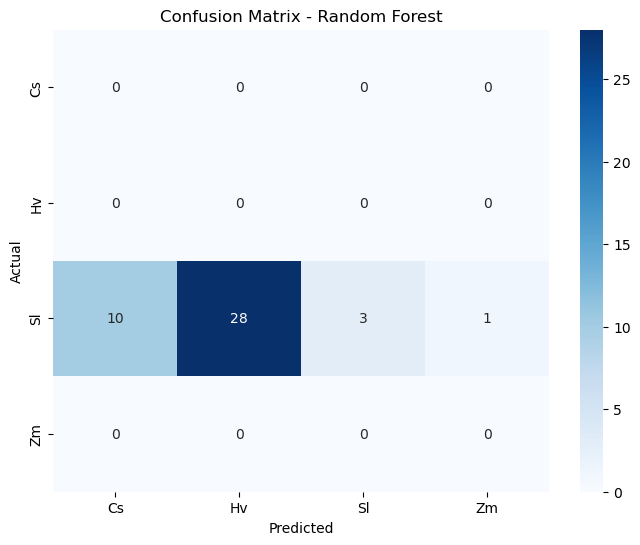

Random Forest shap_values shape is (162, 25, 4)
[[-0.59767351 -0.90585309 -0.90568122 ... -0.08474089 -0.67955921
  -0.77869492]
 [-0.61422813 -0.85846032 -0.85943913 ... -0.18037565 -0.67088312
  -0.76184562]
 [-0.78798406 -0.87454515 -0.86969962 ... -0.1779655  -0.68159372
  -0.82486766]
 ...
 [ 1.24943218  1.60476142  1.59957639 ... -0.33669264  2.14569701
   2.16337183]
 [ 1.14003235  1.72191227  1.71852243 ... -0.47388052  2.20806616
   2.14185503]
 [ 0.91739469  1.61631789  1.60482786 ... -0.76990631  2.09750351
   2.01619043]]
SHAP values shape: (162, 25, 4)
Generating SHAP plots for Class: Cs


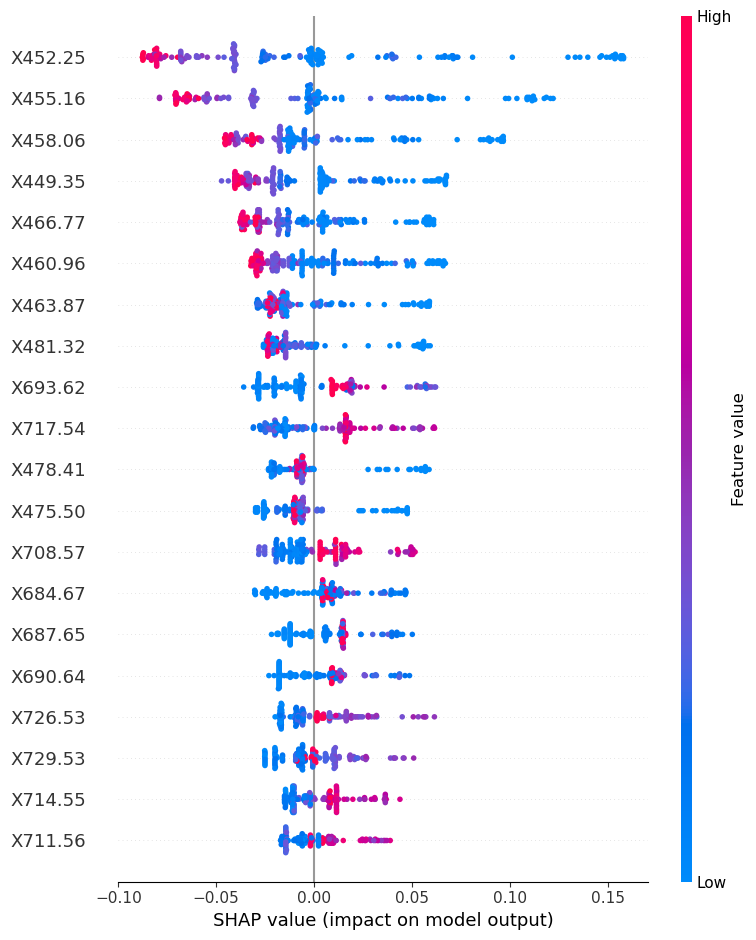

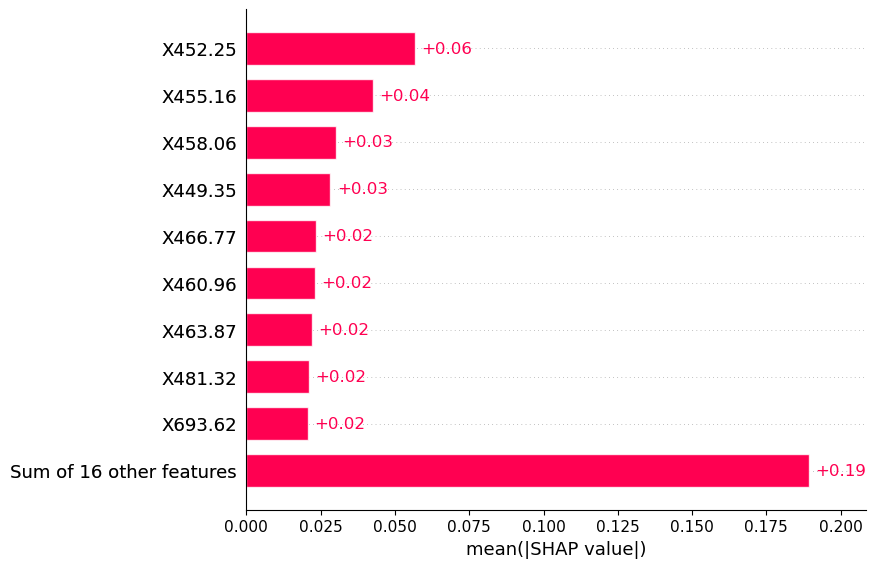

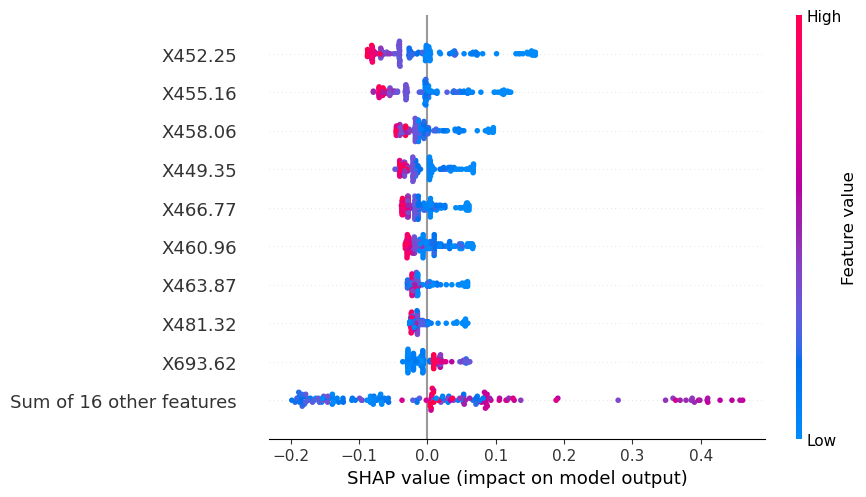

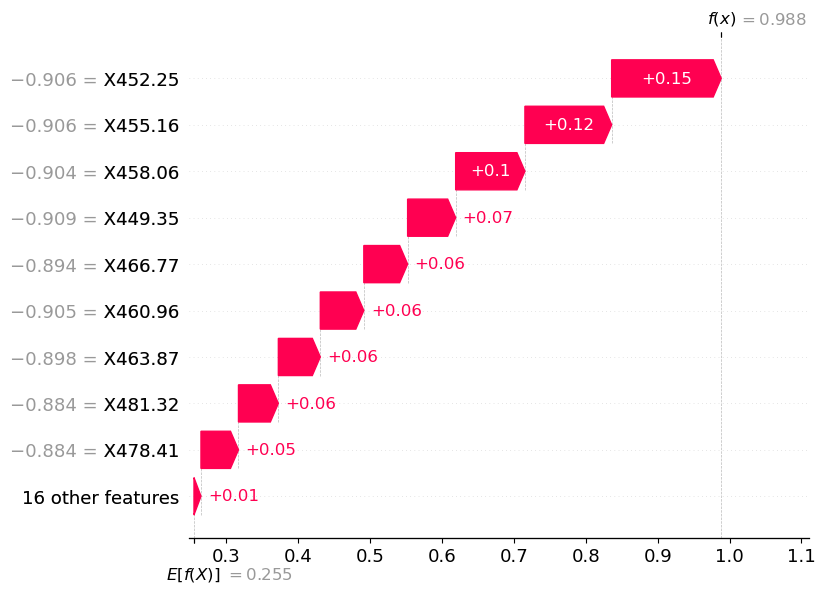

Generating SHAP plots for Class: Hv


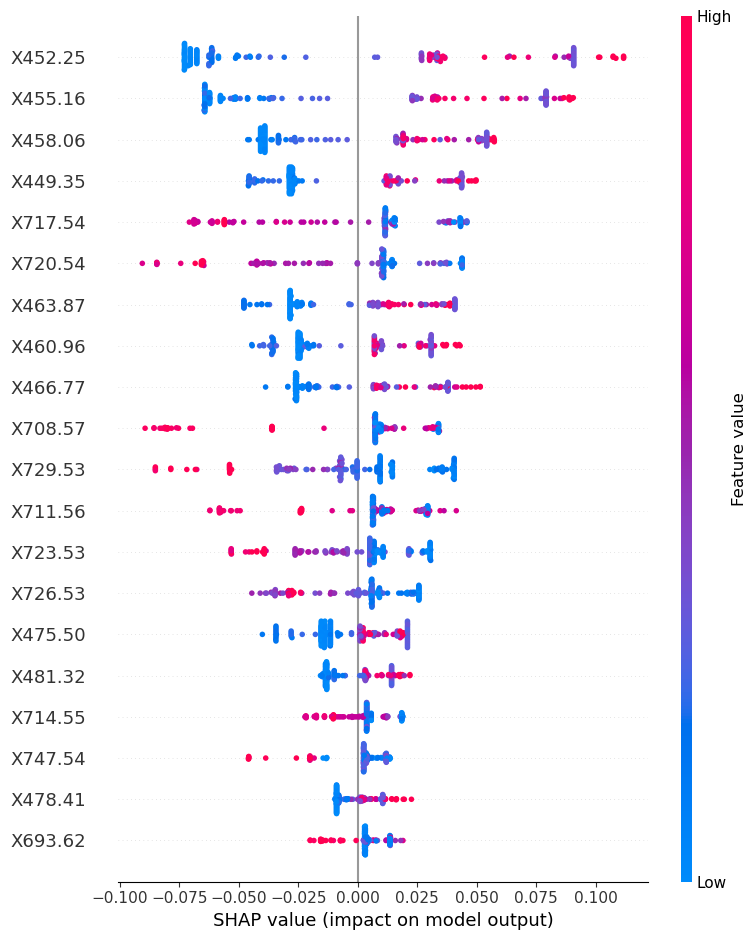

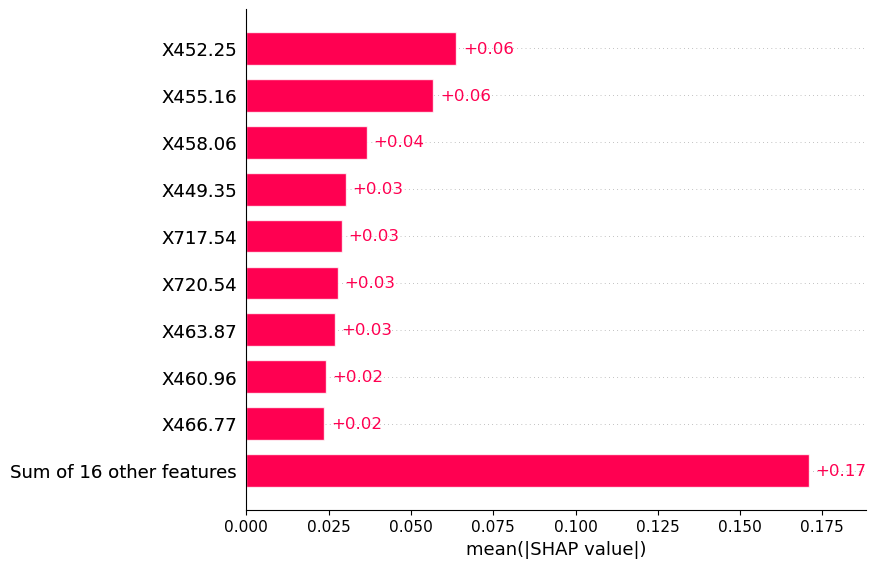

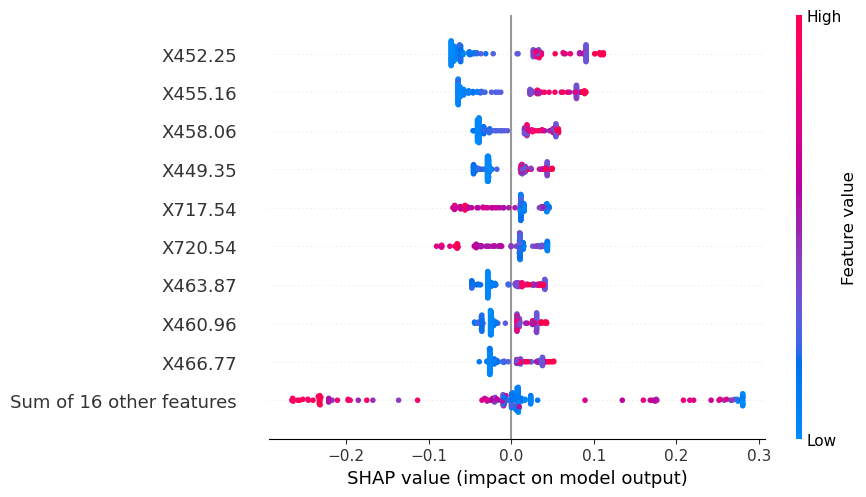

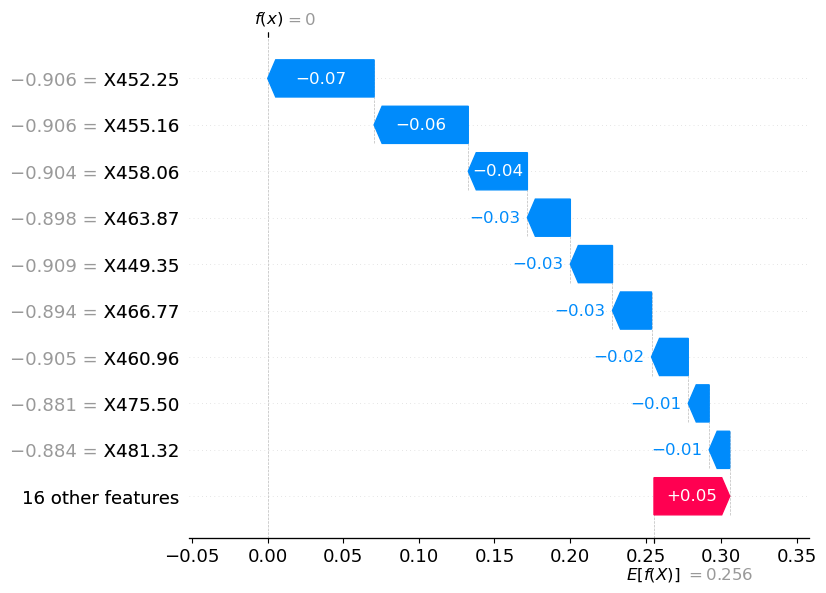

Generating SHAP plots for Class: Sl


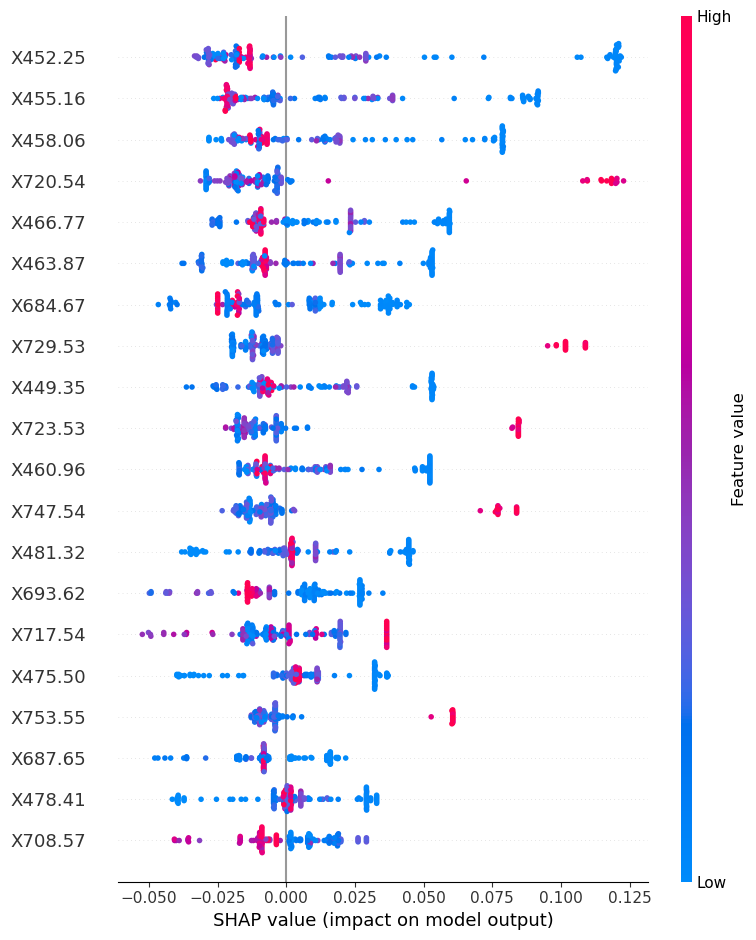

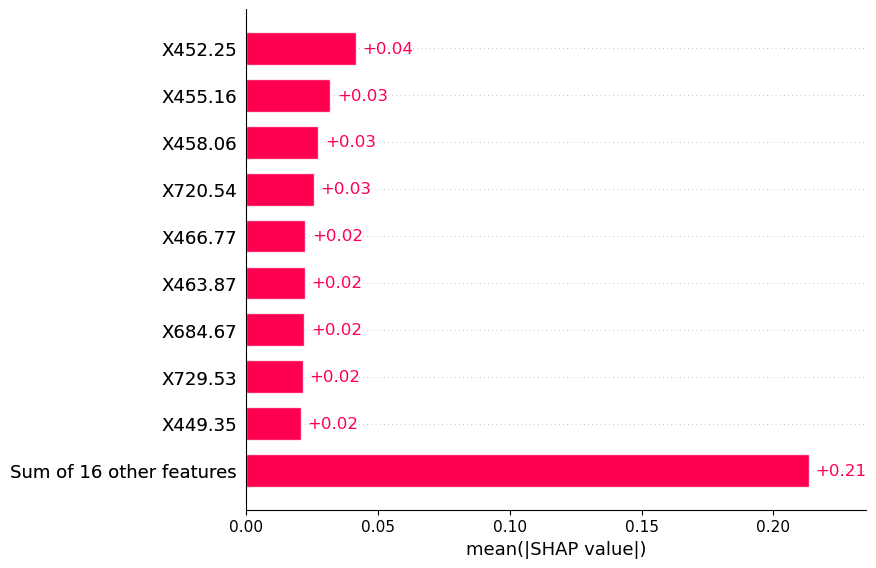

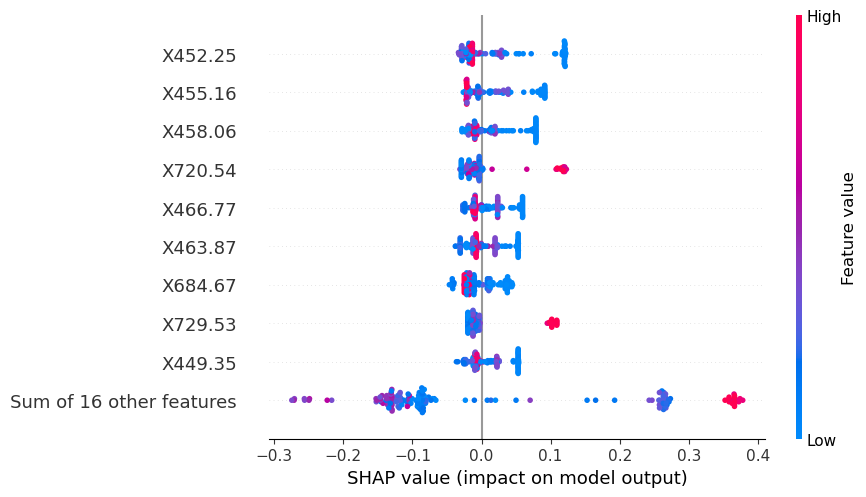

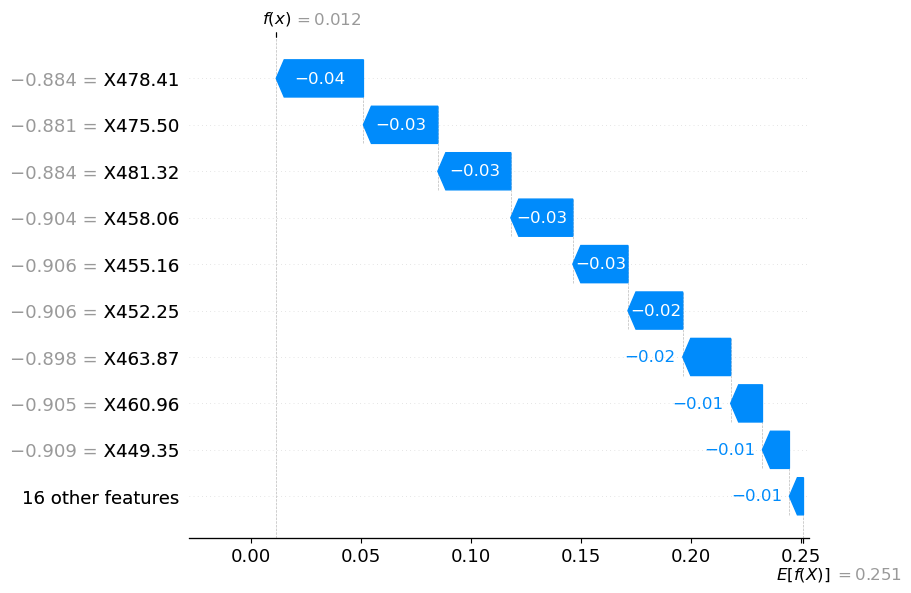

Generating SHAP plots for Class: Zm


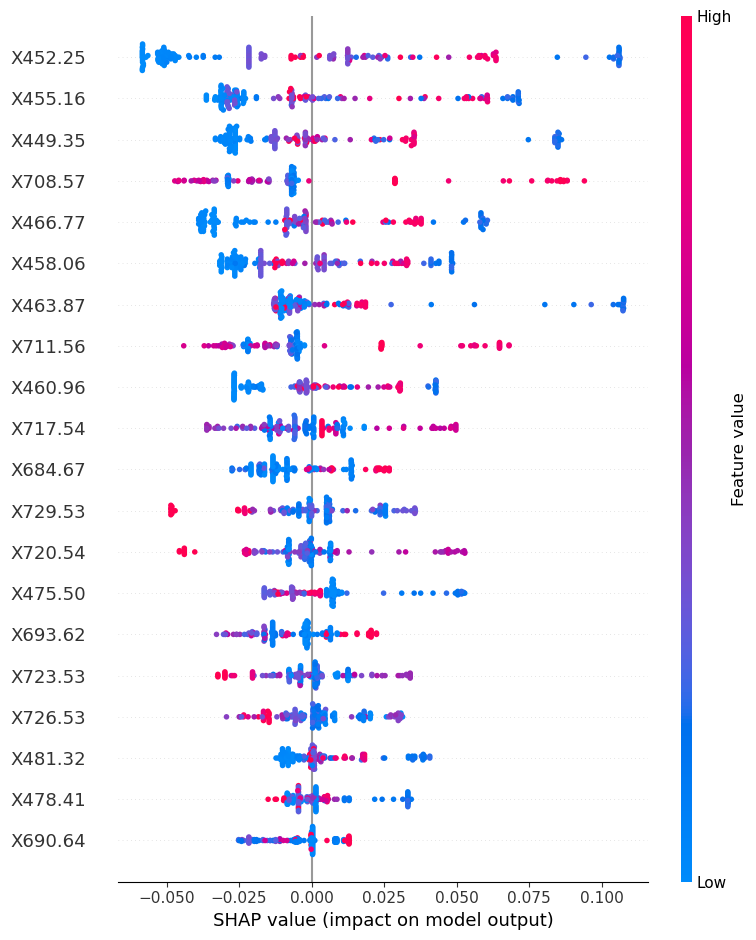

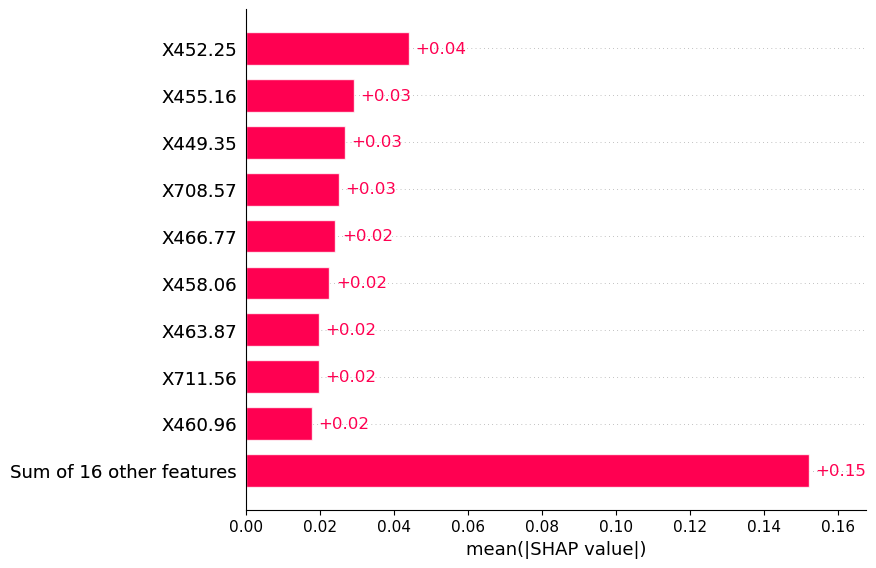

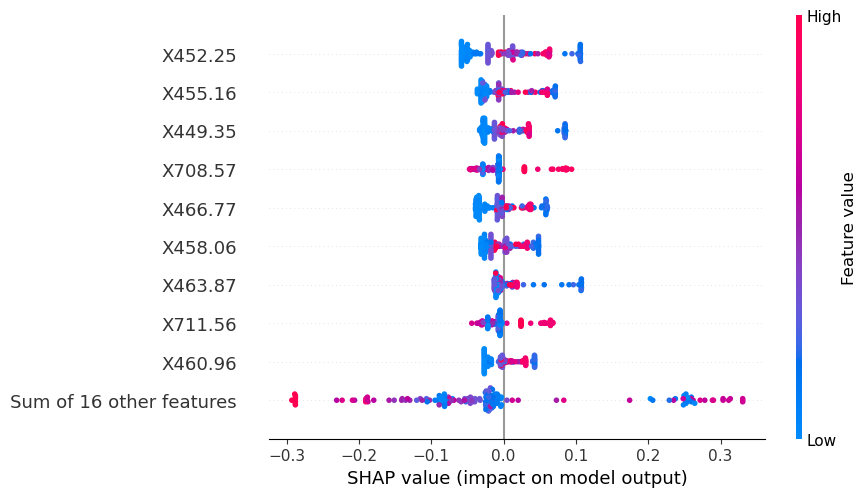

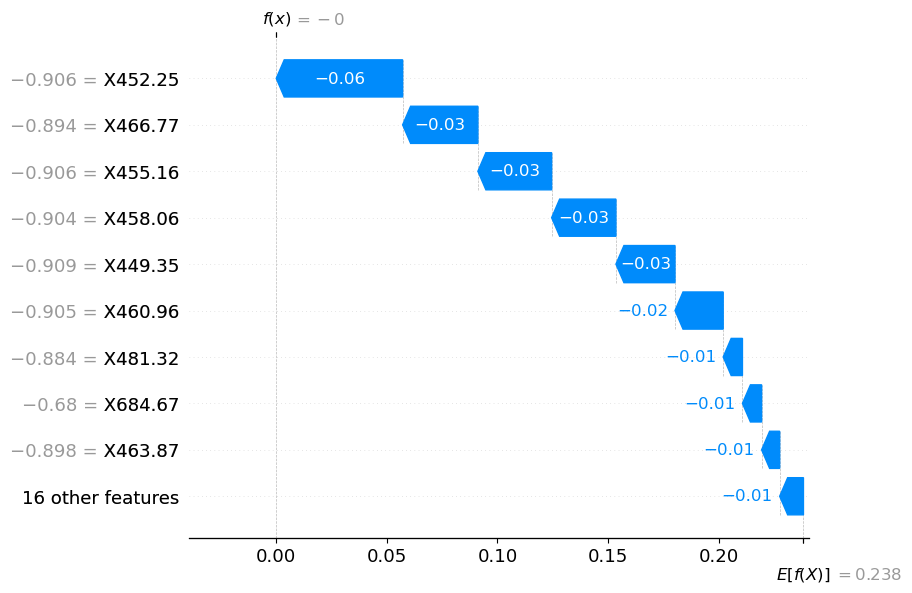

In [78]:
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(class_weight='balanced',**best_params_rf, random_state=random_state)


# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_te, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred_rf,zero_division=0))

print("\nPredicted Probabilities (first 5 instances):")
print(y_pred_proba[:5])
# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Cs", "Hv", "Sl" , "Zm"], yticklabels=["Cs", "Hv", "Sl" , "Zm"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Use TreeExplainer for Random Forest, on the train set
explainer_rf = shap.TreeExplainer(rf_model)
# Calculate SHAP values
# shap_values_rf = explainer_rf.shap_values(X_test)
shap_values_rf = explainer_rf.shap_values(X_train)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))  # Should output (number_of_classes, number_of_samples, number_of_features)

# Ensure X_test is an array
# X_test_array = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
X_train_array = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
print(X_train_array)
# Check the shape of shap_values_rf
print("SHAP values shape:", shap_values_rf.shape)

# Generate all SHAP plots for each class
for i in range(shap_values_rf.shape[2]):
    print(f"Generating SHAP plots for Class: {le.classes_[i]}")

    # Ensure the shapes match for the summary plot
    class_shap_values = shap_values_rf[:, :, i]
    
    # Create an Explanation object for the current class
    shap_explanation = shap.Explanation(
        values=class_shap_values,  # SHAP values for class i
        base_values=explainer_rf.expected_value[i],  # Base values for class i
        # data=X_test_array,
        data=X_train_array,
        # feature_names=feature_names_reduced
        feature_names=feature_names
    )

    # Summary Plot
    shap.summary_plot(shap_explanation,X_train_array, feature_names=feature_names, class_names=le.classes_)
    # shap.summary_plot(shap_explanation,X_test_array, feature_names=feature_names, class_names=le.classes_)
    # shap.summary_plot(shap_explanation, X_test_array, feature_names=feature_names_reduced, class_names=le.classes_)

    # Bar Plot
    shap.plots.bar(shap_explanation, max_display=10)

    # Beeswarm Plot
    shap.plots.beeswarm(shap_explanation)

    # Waterfall Plot for the first instance
    shap.plots.waterfall(shap_explanation[0])



#### Use the following cell as a <font color=red> "stand-alone Logistic Regression" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

In [11]:
# # Function to train and evaluate a model, and compute SHAP values
# def train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names):
#     # Define the parameter grid for Logistic Regression
#     param_grid_lr = {
#         'C': [0.01, 0.1, 1, 10, 30],
#         'penalty': ['l2'],
#         'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
#     }

#     # Initialize the Logistic Regression model
#     lr_model = LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state)

#     # Perform GridSearchCV with cross-validation
#     grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=5, scoring='accuracy')
#     grid_search_lr.fit(X_train, y_train)
#     best_params_lr = grid_search_lr.best_params_
#     print("Best parameters for Logistic Regression:", best_params_lr)

#     # Train the best model on the entire training set
#     best_lr_model = LogisticRegression(**best_params_lr, max_iter=1000, tol=1e-3, random_state=random_state)
#     best_lr_model.fit(X_train, y_train)

#     # Make predictions on the test set
#     y_pred = best_lr_model.predict(X_test)

#     # Evaluate the model
#     accuracy = accuracy_score(y_test, y_pred)
#     print("\nLogistic Regression - Test Set Accuracy:", accuracy)
#     print("Test Set Classification Report:")
#     print(classification_report(y_test, y_pred))

#     # Confusion Matrix
#     conf_matrix = confusion_matrix(y_test, y_pred)

#     # Calculate SHAP values
#     explainer = shap.Explainer(best_lr_model, X_train)
#     shap_values = explainer(X_test)
#     return accuracy, conf_matrix, y_test, y_pred, shap_values, feature_names


# # Initialize random state
# random_state = 42

# # Grouping the data by plant using X_scaled and y
# plant_groups_scaled = {
#     "Plant1": (X_scaled[0:36], y[0:36]),
#     "Plant2": (X_scaled[36:72], y[36:72]),
#     "Plant3": (X_scaled[72:108], y[72:108]),
#     "Plant4": (X_scaled[108:144], y[108:144])
# }

# # 😶😶😶😶😶😶😶😶😶😶😶😶
# # Shuffle the data for each plant once before starting the for loops
# for plant in plant_groups_scaled.keys():
#     X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
#     plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# # Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
# accuracies = []
# conf_matrices = []
# all_y_true = []
# all_y_pred = []
# shap_values_list = []

# # Number of splits
# n_splits = 4

# # Iterate to split the dataset
# for i in range(n_splits):
#     X_train_list = []
#     y_train_list = []
#     X_test_list = []
#     y_test_list = []

#     # Iterate over each plant species
#     for plant in plant_groups_scaled.keys():
#         X = plant_groups_scaled[plant][0]
#         y = plant_groups_scaled[plant][1]
        
#         # Define the indices for the current split
#         test_size = len(X) // n_splits
#         test_indices = range(i * test_size, (i + 1) * test_size)
#         train_indices = list(set(range(len(X))) - set(test_indices))
        
#         # Split the data for the current iteration
#         X_train_plant = X[train_indices]
#         y_train_plant = y[train_indices]
#         X_test_plant = X[test_indices]
#         y_test_plant = y[test_indices]
        
#         # Append to the respective lists
#         X_train_list.append(X_train_plant)
#         y_train_list.append(y_train_plant)
#         X_test_list.append(X_test_plant)
#         y_test_list.append(y_test_plant)

#     # Concatenate the lists to form the final train and test sets
#     X_train = np.concatenate(X_train_list, axis=0)
#     y_train = np.concatenate(y_train_list, axis=0)


#     # 😶😶😶😶😶😶😶😶😶😶😶😶
#     # Shuffle the concatenated train and test sets to remove any order-based bias
#     X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

#     # Confirm the shape of the train and test sets
#     print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
#     print(f"X_test shape: {X_test.shape}, y_te shape: {y_te.shape}")

#     # Train and evaluate the model, and get SHAP values
#     accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names = train_evaluate_shap(X_train, y_train, X_test, y_te, feature_names)
#     # accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names = train_evaluate_shap(X_train, y_train, X_test, y_te, feature_names_reduced)
#     accuracies.append(accuracy)
#     conf_matrices.append(conf_matrix)
#     all_y_true.extend(y_true)
#     all_y_pred.extend(y_pred)
#     shap_values_list.append(shap_values)

#     # Plot the confusion matrix for each iteration
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.title(f"Confusion Matrix - Iteration {i+1}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

# # Calculate the average accuracy
# average_accuracy = np.mean(accuracies)
# print("\nAverage Accuracy Across 4 Iterations:", average_accuracy)

# # Combine confusion matrices by summing them up
# combined_conf_matrix = np.sum(conf_matrices, axis=0)

# # Plot the combined confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(combined_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Combined Confusion Matrix - Logistic Regression")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Calculate precision, recall, and F1-score using the aggregated results
# precision = precision_score(all_y_true, all_y_pred, average='micro')
# recall = recall_score(all_y_true, all_y_pred, average='micro')
# f1 = f1_score(all_y_true, all_y_pred, average='micro')

# print(f"\nOverall Precision: {precision}")
# print(f"Overall Recall: {recall}")
# print(f"Overall F1-score: {f1}")

# # Aggregate SHAP values
# mean_shap_values = np.mean([sv.values for sv in shap_values_list], axis=0)
# combined_base_values = np.mean([sv.base_values for sv in shap_values_list], axis=0)

# # Assuming X_test from the last iteration, or a combined test set
# # Create an Explanation object with combined SHAP values
# combined_explanation = shap.Explanation(
#     values=mean_shap_values,
#     base_values=combined_base_values,
#     data=X_test,
#     feature_names=feature_names
#     # feature_names=feature_names_reduced
# )

# # Print the length of feature names in combined_explanation
# print("Length of feature names in combined_explanation:", len(combined_explanation.feature_names))

# # Generate SHAP plots for each class
# # Generate SHAP plots for binary classification or regression
# print("Generating SHAP plots for Binary Classification/Regression")

# # Generate SHAP plots for each class
# for i in range(combined_explanation.shape[2]):
#     print(f"Generating SHAP plots for Class: {le.classes_[i]}")

#     # Summary Plot
#     shap.summary_plot(combined_explanation.values[:, :, i],X_test, feature_names=combined_explanation.feature_names)
    
#     # Bar Plot
#     shap.plots.bar(shap.Explanation(
#         values=combined_explanation.values[:, :, i],
#         base_values=combined_explanation.base_values[:, i],
#         data=X_test,
#         feature_names=combined_explanation.feature_names
#     ), max_display=10)
    
#     # Beeswarm Plot
#     shap.plots.beeswarm(shap.Explanation(
#         values=combined_explanation.values[:, :, i],
#         base_values=combined_explanation.base_values[:, i],
#         data= X_test,
#         feature_names=combined_explanation.feature_names
#     ))
    
#     # # Waterfall Plot for the first instance
#     # shap.plots.waterfall(shap.Explanation(
#     #     values=combined_explanation.values[0, :, i],
#     #     base_values=combined_explanation.base_values[0, i],
#     #     data=X_test[0],
#     #     feature_names=combined_explanation.feature_names
#     # ))

#### Use the following cell as a <font color=red> "stand-alone RandomForest" </font> for plan C Prime split
#### run from the last cell each time, or the sizes will collapse and it will engender error!

In [12]:
# # Function to train and evaluate a model, and compute SHAP values
# def train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names):
#     # Define the parameter grid for Random Forest
#     param_grid_rf = {
#         'n_estimators': [10, 50, 100, 200],
#         'max_depth': [None, 10, 20, 30],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'max_features': ['sqrt', 'log2']
#     }
#     random_state = 42

#     # Perform GridSearchCV with cross-validation
#     grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
#     grid_search_rf.fit(X_train, y_train)
#     best_params_rf = grid_search_rf.best_params_
#     print("Best parameters for Random Forest:", best_params_rf)

#     # Initialize the best Random Forest model
#     best_rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)
#     best_rf_model.fit(X_train, y_train)

#     # Make predictions on the test set
#     y_pred_rf = best_rf_model.predict(X_test)

#     # Evaluate the model
#     accuracy_rf = accuracy_score(y_test, y_pred_rf)
#     print("\nRandom Forest - Test Set Accuracy:", accuracy_rf)
#     print("Test Set Classification Report:")
#     print(classification_report(y_test, y_pred_rf))

#     # Confusion Matrix
#     conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

#     # Calculate SHAP values using TreeExplainer
#     explainer_rf = shap.TreeExplainer(best_rf_model)
#     shap_values_rf = explainer_rf.shap_values(X_test)
#     print("shap_values_rf's shape", shap_values_rf.shape)
#     return accuracy_rf, conf_matrix_rf, y_test, y_pred_rf, shap_values_rf, explainer_rf, feature_names

# # Initialize random state
# random_state = 42

# # Grouping the data by plant using X_scaled and y
# plant_groups_scaled = {
#     "Plant1": (X_scaled[0:36], y[0:36]),
#     "Plant2": (X_scaled[36:72], y[36:72]),
#     "Plant3": (X_scaled[72:108], y[72:108]),
#     "Plant4": (X_scaled[108:144], y[108:144])
# }

# # 😶😶😶😶😶😶😶😶😶😶😶😶
# # Shuffle the data for each plant once before starting the for loops
# for plant in plant_groups_scaled.keys():
#     X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
#     plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# # Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
# accuracies_rf = []
# conf_matrices_rf = []
# all_y_true_rf = []
# all_y_pred_rf = []
# shap_values_list_rf = []
# explainer_rf_list = []

# # Number of splits
# n_splits = 4

# # Iterate to split the dataset
# for i in range(n_splits):
#     X_train_list = []
#     y_train_list = []
#     X_test_list = []
#     y_test_list = []

#     # Iterate over each plant species
#     for plant in plant_groups_scaled.keys():
#         X = plant_groups_scaled[plant][0]
#         y = plant_groups_scaled[plant][1]
        
#         # Define the indices for the current split
#         test_size = len(X) // n_splits
#         test_indices = range(i * test_size, (i + 1) * test_size)
#         train_indices = list(set(range(len(X))) - set(test_indices))
        
#         # Split the data for the current iteration
#         X_train_plant = X[train_indices]
#         y_train_plant = y[train_indices]
#         X_test_plant = X[test_indices]
#         y_test_plant = y[test_indices]
        
#         # Append to the respective lists
#         X_train_list.append(X_train_plant)
#         y_train_list.append(y_train_plant)
#         X_test_list.append(X_test_plant)
#         y_test_list.append(y_test_plant)

#     # Concatenate the lists to form the final train and test sets
#     X_train = np.concatenate(X_train_list, axis=0)
#     y_train = np.concatenate(y_train_list, axis=0)
  

#     # 😶😶😶😶😶😶😶😶😶😶😶😶
#     # Shuffle the concatenated train and test sets to remove any order-based bias
#     X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    
#     # Confirm the shape of the train and test sets
#     print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
#     print(f"X_test shape: {X_test.shape}, y_te shape: {y_te.shape}")

#     # Train and evaluate the model, and get SHAP values
#     accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_te, feature_names)
#     # accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_te, feature_names_reduced)

    
#     accuracies_rf.append(accuracy_rf)
#     conf_matrices_rf.append(conf_matrix_rf)
#     all_y_true_rf.extend(y_true_rf)
#     all_y_pred_rf.extend(y_pred_rf)
#     shap_values_list_rf.append(shap_values_rf)
#     explainer_rf_list.append(explainer_rf)

#     # Plot the confusion matrix for each iteration
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.title(f"Confusion Matrix - Iteration {i+1}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

# # Calculate the average accuracy
# average_accuracy_rf = np.mean(accuracies_rf)
# print("\nAverage Accuracy Across 4 Iterations:", average_accuracy_rf)

# # Combine confusion matrices by summing them up
# # Combine confusion matrices by summing them up
# combined_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)

# # Plot the combined confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(combined_conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Combined Confusion Matrix - Random Forest")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Calculate precision, recall, and F1-score using the aggregated results
# precision_rf = precision_score(all_y_true_rf, all_y_pred_rf, average='micro')
# recall_rf = recall_score(all_y_true_rf, all_y_pred_rf, average='micro')
# f1_rf = f1_score(all_y_true_rf, all_y_pred_rf, average='micro')

# print(f"\nOverall Precision: {precision_rf}")
# print(f"Overall Recall: {recall_rf}")
# print(f"Overall F1-score: {f1_rf}")

# # Aggregate SHAP values
# mean_shap_values_rf = np.mean([sv for sv in shap_values_list_rf], axis=0)
# combined_base_values_rf = np.mean([explainer.expected_value for explainer in explainer_rf_list], axis=0)
# print("combined_base_values_rf's shape", combined_base_values_rf)


# # Aggregate SHAP values
# mean_shap_values_rf = np.mean([sv for sv in shap_values_list_rf], axis=0)
# combined_base_values_rf = np.mean([explainer.expected_value for explainer in explainer_rf_list], axis=0)
# print("combined_base_values_rf's shape", combined_base_values_rf)


# # Create an Explanation object with combined SHAP values
# combined_explanation_rf = shap.Explanation(
#     values=mean_shap_values_rf[:, :, i],
#     base_values=combined_base_values_rf,
#     data=X_test,
#     feature_names=feature_names
#     # feature_names=feature_names_reduced
# )

# # Generate SHAP plots for each class
# for i in range(shap_values_rf.shape[2]):
#     print(f"Generating SHAP plots for Class: {le.classes_[i]}")

#     # Summary Plot
#     shap.summary_plot(combined_explanation_rf)
    
#     # Bar Plot
#     shap.plots.bar(combined_explanation_rf)
    
#     # Beeswarm Plot
#     shap.plots.beeswarm(combined_explanation_rf)
